# Metacatalog source quality flags

Attach a **32-bit `quality_flag`** to every merged source. Rows are **not** dropped:
each bit encodes a property or quality concern so downstream cuts can be composed
with `quality_flag == 0` (all checks passed) or `quality_flag & MASK == 0`.

**Convention:** a bit is **0 if that check is good/reliable** and **1** if the
property is a concern. Bits 17–31 are reserved (stay 0).

| Bit | Name | Set (1) when |
|---:|---|---|
| 0 | `HAS_NAN` | a core measurement column is NaN (not per-band extras) |
| 1 | `INVALID_ASTROMETRY` | RA, DEC, or Peak_flux is non-finite (was E0) |
| 2 | `SINGLE_LST` | `n_lst_contributions == 1` |
| 3 | `SINGLE_UNIQUE_BAND` | uniquely associated in exactly one band (`n_assoc==1`; Full/seed band counts) |
| 4 | `UNPHYSICAL_FLUX` | `(Total−Peak)/hypot(E) < −3` (was E2) |
| 5 | `RESID_ABS_FAIL` | island RMS or \|mean\| above absolute Jy/beam cuts (was E3) |
| 6 | `RESID_PCTL_RMS` | `Resid_Isl_rms` outside the catalog 1–99 percentile |
| 7 | `RESID_PCTL_MEAN` | `Resid_Isl_mean` outside the catalog 1–99 percentile |
| 8 | `JITTER_FAIL` | cluster RMS `> 0.3 × BMAJ` (was E4) |
| 9 | `CONFUSED_ASSOC` | any `n_assoc_* > 1` (was E5) |
| 10 | `NO_VLSSR` | no positional match to the VLSSR catalog |
| 11 | `SCODE_COMPLEX` | PyBDSF `S_Code` is `C` or `M` |
| 12 | `LOW_ELEVATION` | elevation at `representative_lst` &lt; 10° |
| 13 | `HIGH_ELLIPTICITY` | `Maj / Min > 3` (source FWHM axes) |
| 14 | `EXTENDED` | `Maj > 3 × BMAJ` |
| 15 | `LARGE_SINGLE` | (`EXTENDED` or `HIGH_ELLIPTICITY`) and (`SINGLE_UNIQUE_BAND` or `SINGLE_LST`) |
| 16 | `NEAR_BRIGHT_SIDELOBE` | within `sidelobe_sep_bmaj_lo`–`hi` × bright-neighbor BMAJ of a source ≥`sidelobe_flux_ratio`× brighter (defaults 2–4× / 30×; set on `CONFIG`) |

Residuals, unphysical flux, and jitter still use the **origin-band seeded LST row**.
α corner cuts are **not** encoded. ``quality_flag`` is written onto
``metacatalog.parquet`` (overwrites the fusion file after reliability runs).

Works with **RGB/Full** catalogs (`Full`, `Blue`, `Green`, `Red`) and **frequency-labeled**
subbands (e.g. `18MHz` … `82MHz`; no top-level `Peak_flux` — flux is per-subband; `astrometry_band` is the highest-frequency measurement on each row).

Requires `lwa-catalog[analyze]` (`healpy` for binning, `lwa-healpix` for HiPS export).
The **HiPS sky viewer** at the end also needs `lwa-catalog[viz]` (`panel` + `ipyaladin`).

Set ``REUSE_CACHED_RELIABILITY = True`` to load existing
``metacatalog.parquet`` (with ``quality_flag``) / ``metacatalog_quality_flags.parquet``
(and existing HiPS directories) instead of recomputing or writing outputs.

**Run cells in order.** Reload this notebook from disk and restart the kernel if it still
imports `filter_metacatalog_reliability` as the main product.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from lwa_catalog.analyze import (
    QualityFlagResult,
    ReliabilityConfig,
    SourceQualityFlag,
    assign_source_quality_flags,
    decode_quality_flag,
    filter_by_quality_mask,
    is_subband_metacatalog,
    load_vlssr_catalog,
    metacatalog_to_healpix,
    quality_flag_legend,
    quality_flag_mask_from_names,
    representative_peak_flux,
    write_healpix_hips,
)
from lwa_catalog.constants import SUBBAND_METACATALOG_REQUIRED_COLUMNS
from lwa_catalog.io import (
    discover_lst_merged_bands,
    read_all_lst_merged,
    read_metacatalog,
    read_table,
    seed_band_from_discovery,
    write_metacatalog,
    write_table,
)
from lwa_catalog.paths import CatalogLayout

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_IdTR-0.75_shflux_subband")  # existing fusion tree
NSIDE = 512
REUSE_CACHED_RELIABILITY = False  # load cached Parquet/HiPS; skip all writes when True
# HiPS output directory name under CATALOG_DIR; fields: {name} (full|core_clean|…), {nside}
HIPS_DIR_TEMPLATE = "metacatalog_IdTR-0.75_shflux_subband_{name}.hips"
WRITE_SUBSET = False
# NEAR_BRIGHT_SIDELOBE: faint source in [lo, hi] × bright-neighbor BMAJ
# with Peak_flux_bright / Peak_flux_faint ≥ flux_ratio.
CONFIG = ReliabilityConfig(
    resid_rms_thresh_jy=2.0,
    resid_mean_thresh_jy=2.0,
    resid_percentile_lo=1.0,
    resid_percentile_hi=99.0,
    jitter_bmaj_frac=0.3,
    min_elevation_deg=10.0,
    max_source_ellipticity=3.0,
    sidelobe_sep_bmaj_lo=1.0,
    sidelobe_sep_bmaj_hi=2.0,
    sidelobe_flux_ratio=50.0,
)

layout = CatalogLayout(CATALOG_DIR)
BANDS = discover_lst_merged_bands(layout)
SEED_BAND = seed_band_from_discovery(BANDS)
# Subband HiPS maps weight Gaussians by Peak_flux at this band (default: highest-frequency seed).
HIPS_FLUX_BAND = SEED_BAND
# Default exclusion set: drop rows with any of these quality bits set.
EXCLUDE_FLAGS = (
    "HAS_NAN",
    "INVALID_ASTROMETRY",
    "UNPHYSICAL_FLUX",
    "RESID_ABS_FAIL",
    "RESID_PCTL_RMS",
    "RESID_PCTL_MEAN",
    "JITTER_FAIL",
    "LARGE_SINGLE",
    "NEAR_BRIGHT_SIDELOBE",
)
EXCLUDE_MASK = quality_flag_mask_from_names(EXCLUDE_FLAGS)
# HiPS ``core_clean`` uses the same default exclusion mask.
HIPS_CORE_CLEAN_FLAGS = EXCLUDE_FLAGS
HIPS_CORE_CLEAN_MASK = EXCLUDE_MASK

PATHS = {
    "metacatalog": layout.metacatalog(),
    "flags": layout.metacatalog_quality_flags(),
}
print("CATALOG_DIR =", layout.root.resolve())
print("BANDS =", BANDS)
print("SEED_BAND =", SEED_BAND)
print("REUSE_CACHED_RELIABILITY =", REUSE_CACHED_RELIABILITY)
print("HIPS_DIR_TEMPLATE =", HIPS_DIR_TEMPLATE)
print("EXCLUDE_FLAGS =", EXCLUDE_FLAGS)
print("EXCLUDE_MASK =", EXCLUDE_MASK)
print(
    "sidelobe: sep_bmaj=[{}, {}], flux_ratio={}".format(
        CONFIG.sidelobe_sep_bmaj_lo,
        CONFIG.sidelobe_sep_bmaj_hi,
        CONFIG.sidelobe_flux_ratio,
    )
)
display(quality_flag_legend())


CATALOG_DIR = /fast/claw/metacatalog_IdTR-0.75_shflux_subband
BANDS = ('18MHz', '23MHz', '27MHz', '32MHz', '36MHz', '41MHz', '46MHz', '50MHz', '55MHz', '59MHz', '64MHz', '69MHz', '73MHz', '78MHz', '82MHz')
SEED_BAND = 82MHz
REUSE_CACHED_RELIABILITY = False
HIPS_DIR_TEMPLATE = metacatalog_IdTR-0.75_shflux_subband_{name}.hips
EXCLUDE_FLAGS = ('HAS_NAN', 'INVALID_ASTROMETRY', 'UNPHYSICAL_FLUX', 'RESID_ABS_FAIL', 'RESID_PCTL_RMS', 'RESID_PCTL_MEAN', 'JITTER_FAIL', 'LARGE_SINGLE', 'NEAR_BRIGHT_SIDELOBE')
EXCLUDE_MASK = 98803
sidelobe: sep_bmaj=[1.0, 2.0], flux_ratio=50.0


,bit,value,name,meaning
0,0,1,HAS_NAN,core measurement column is NaN
1,1,2,INVALID_ASTROMETRY,"RA, DEC, or Peak_flux is non-finite"
2,2,4,SINGLE_LST,n_lst_contributions == 1
3,3,8,SINGLE_UNIQUE_BAND,uniquely associated in exactly one band
4,4,16,UNPHYSICAL_FLUX,(Total-Peak)/hypot(E) < -3
5,5,32,RESID_ABS_FAIL,Resid_Isl_rms or |Resid_Isl_mean| above absolu...
6,6,64,RESID_PCTL_RMS,Resid_Isl_rms outside catalog 1–99 percentile
7,7,128,RESID_PCTL_MEAN,Resid_Isl_mean outside catalog 1–99 percentile
8,8,256,JITTER_FAIL,cluster RA/Dec RMS > 0.3 × BMAJ
9,9,512,CONFUSED_ASSOC,any n_assoc_* > 1


## Load metacatalog + LST-merged cache

In [2]:
# Read metacatalog with no quality row filter (recompute may overwrite quality_flag).
metacatalog = read_metacatalog(layout, quality_mask=None)
print(f"metacatalog rows: {len(metacatalog)}")

_cache_ready = (
    REUSE_CACHED_RELIABILITY
    and PATHS["metacatalog"].is_file()
    and "quality_flag" in metacatalog.columns
    and PATHS["flags"].is_file()
)
if _cache_ready:
    lst_merged = None
    vlssr = None
    print("Cache hit for quality flags — skipping LST-merged / VLSSR load")
else:
    lst_merged = read_all_lst_merged(layout, bands=BANDS)
    for band, df in lst_merged.items():
        print(f"  LST {band}: {len(df)} rows")
    try:
        vlssr = load_vlssr_catalog()
        print(f"VLSSR rows: {len(vlssr)}")
    except FileNotFoundError as exc:
        vlssr = None
        print(f"VLSSR not loaded ({exc}); NO_VLSSR bit will be skipped")


metacatalog rows: 197696
  LST 18MHz: 10995 rows
  LST 23MHz: 17775 rows
  LST 27MHz: 25752 rows
  LST 32MHz: 34944 rows
  LST 36MHz: 44987 rows
  LST 41MHz: 60383 rows
  LST 46MHz: 72388 rows
  LST 50MHz: 83996 rows
  LST 55MHz: 95802 rows
  LST 59MHz: 106742 rows
  LST 64MHz: 123139 rows
  LST 69MHz: 130212 rows
  LST 73MHz: 139434 rows
  LST 78MHz: 149794 rows
  LST 82MHz: 133945 rows
VLSSR rows: 92965


In [3]:
metacatalog

,meta_id,origin_band,bands_present,RA,DEC,Maj,Min,PA,DC_Maj,DC_Min,...,source_file_59MHz,source_file_55MHz,source_file_50MHz,source_file_46MHz,source_file_41MHz,source_file_36MHz,source_file_32MHz,source_file_27MHz,source_file_23MHz,source_file_18MHz
0,134097,78MHz,"78MHz,73MHz,46MHz,41MHz,32MHz,18MHz",260.343332,-1.015527,0.154958,0.114274,16.366432,0.103294,0.062374,...,None,None,None,46MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,41MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,32MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,None,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...
1,5722,82MHz,"82MHz,59MHz,18MHz",259.722484,-1.107120,0.270208,0.229069,73.432705,0.197105,0.142653,...,59MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,None,None,None,None,None,None,None,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...
2,168987,73MHz,"73MHz,69MHz,18MHz",259.813579,-0.779135,0.365483,0.185072,33.146464,0.295117,0.114668,...,None,None,None,None,None,None,None,None,None,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...
3,194267,55MHz,"55MHz,50MHz,32MHz,27MHz,23MHz,18MHz",260.174424,-1.188403,0.155661,0.146921,73.988994,0.000000,0.000000,...,None,55MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,50MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,None,None,32MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,27MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,23MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...
4,120,82MHz,"82MHz,69MHz,64MHz,59MHz,46MHz,41MHz,36MHz,32MH...",260.088627,-0.921315,0.186070,0.070538,36.838552,0.149574,0.000000,...,59MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,None,46MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,41MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,36MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,32MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,None,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197691,187846,69MHz,69MHz,163.441982,41.197607,0.142014,0.103691,48.339854,0.091222,0.034820,...,None,None,None,None,None,None,None,None,None,None
197692,168958,78MHz,78MHz,160.288857,41.655371,0.188785,0.127455,103.200362,0.166329,0.082320,...,None,None,None,None,None,None,None,None,None,None
197693,181191,73MHz,73MHz,203.972635,14.823759,0.114747,0.093860,94.443633,0.000000,0.000000,...,None,None,None,None,None,None,None,None,None,None
197694,133943,82MHz,82MHz,262.193006,29.788792,0.096889,0.076070,97.264498,0.000000,0.000000,...,None,None,None,None,None,None,None,None,None,None


## Load or compute quality flags

With ``REUSE_CACHED_RELIABILITY=True``, load ``metacatalog.parquet`` (must already
carry ``quality_flag``) and ``metacatalog_quality_flags.parquet``. If cache
files are missing, flags still run in memory but **no Parquet or HiPS files are
written**. Set the flag to ``False`` to regenerate and write outputs.

Every input row is retained. Use ``quality.catalog.query("quality_flag == 0")``
for the all-clear subset, or mask individual bits with
``SourceQualityFlag`` / ``decode_quality_flag``.


In [4]:
def _quality_from_parquet(catalog_path: Path, flags_path: Path) -> QualityFlagResult:
    cat = read_table(catalog_path)
    flags = read_table(flags_path) if flags_path.is_file() else pd.DataFrame()
    return QualityFlagResult(
        catalog=cat,
        flags=flags,
        bit_counts=quality_flag_bit_counts(flags if not flags.empty else cat),
        warnings=[f"loaded from {catalog_path.name}"],
    )


_cache_ready = (
    REUSE_CACHED_RELIABILITY
    and PATHS["metacatalog"].is_file()
    and "quality_flag" in metacatalog.columns
    and PATHS["flags"].is_file()
)
if _cache_ready:
    quality = _quality_from_parquet(PATHS["metacatalog"], PATHS["flags"])
    print(f"Loaded cached quality flags: n={len(quality.catalog)}")
else:
    if REUSE_CACHED_RELIABILITY:
        print("Cache missing — regenerating quality flags…")
    quality = assign_source_quality_flags(
        metacatalog,
        layout,
        config=CONFIG,
        lst_merged=lst_merged,
        vlssr=vlssr,
    )

n = len(quality.catalog)
n_clear = int((quality.catalog["quality_flag"] == 0).sum())
print(f"n_sources = {n}")
print(f"n_all_clear (quality_flag==0) = {n_clear}")
if quality.warnings:
    print("warnings:")
    for w in quality.warnings[:12]:
        print(f"  - {w}")
    if len(quality.warnings) > 12:
        print(f"  … {len(quality.warnings) - 12} more")

display(quality.bit_counts)

reliable = quality.catalog.loc[quality.catalog["quality_flag"] == 0]
flagged = quality.catalog.loc[quality.catalog["quality_flag"] != 0]
core_clean = filter_by_quality_mask(quality.catalog, HIPS_CORE_CLEAN_MASK)
print(
    f"reliable={len(reliable)}  flagged={len(flagged)}  "
    f"core_clean={len(core_clean)}"
)
display(quality.catalog.head(5))
if len(flagged):
    sample = flagged.head(5).copy()
    sample["flag_names"] = sample["quality_flag"].map(
        lambda v: ", ".join(decode_quality_flag(int(v)))
    )
    if is_subband_metacatalog(sample):
        sample["_Peak_flux"] = representative_peak_flux(sample)
        show_cols = ["meta_id", "RA", "DEC", "astrometry_band", "_Peak_flux", "quality_flag", "flag_names"]
    else:
        show_cols = ["meta_id", "RA", "DEC", "Peak_flux", "quality_flag", "flag_names"]
    display(sample[[c for c in show_cols if c in sample.columns]])

# Example: keep sources that are multi-LST and VLSSR-matched, ignoring other bits
# mask = int(SourceQualityFlag.SINGLE_LST | SourceQualityFlag.NO_VLSSR)
# subset = quality.catalog.loc[quality.catalog["quality_flag"] & mask == 0]


n_sources = 197696
n_all_clear (quality_flag==0) = 79262
warnings:
  - using merge-time cluster jitter (skipping per-hour rematch)


,bit,name,n_set,fraction,meaning
0,0,HAS_NAN,0,0.000000,core measurement column is NaN
1,1,INVALID_ASTROMETRY,0,0.000000,"RA, DEC, or Peak_flux is non-finite"
2,2,SINGLE_LST,18946,0.095834,n_lst_contributions == 1
3,3,SINGLE_UNIQUE_BAND,20421,0.103295,uniquely associated in exactly one band
4,4,UNPHYSICAL_FLUX,416,0.002104,(Total-Peak)/hypot(E) < -3
5,5,RESID_ABS_FAIL,513,0.002595,Resid_Isl_rms or |Resid_Isl_mean| above absolu...
6,6,RESID_PCTL_RMS,3953,0.019995,Resid_Isl_rms outside catalog 1–99 percentile
7,7,RESID_PCTL_MEAN,3954,0.020000,Resid_Isl_mean outside catalog 1–99 percentile
8,8,JITTER_FAIL,2793,0.014128,cluster RA/Dec RMS > 0.3 × BMAJ
9,9,CONFUSED_ASSOC,7174,0.036288,any n_assoc_* > 1


reliable=79262  flagged=118434  core_clean=185124


,meta_id,origin_band,bands_present,RA,DEC,Maj,Min,PA,DC_Maj,DC_Min,...,source_file_55MHz,source_file_50MHz,source_file_46MHz,source_file_41MHz,source_file_36MHz,source_file_32MHz,source_file_27MHz,source_file_23MHz,source_file_18MHz,quality_flag
0,134097,78MHz,"78MHz,73MHz,46MHz,41MHz,32MHz,18MHz",260.343332,-1.015527,0.154958,0.114274,16.366432,0.103294,0.062374,...,None,None,46MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,41MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,32MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,None,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,2304
1,5722,82MHz,"82MHz,59MHz,18MHz",259.722484,-1.107120,0.270208,0.229069,73.432705,0.197105,0.142653,...,None,None,None,None,None,None,None,None,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,0
2,168987,73MHz,"73MHz,69MHz,18MHz",259.813579,-0.779135,0.365483,0.185072,33.146464,0.295117,0.114668,...,None,None,None,None,None,None,None,None,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,2240
3,194267,55MHz,"55MHz,50MHz,32MHz,27MHz,23MHz,18MHz",260.174424,-1.188403,0.155661,0.146921,73.988994,0.000000,0.000000,...,55MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,50MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,None,None,32MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,27MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,23MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,2528
4,120,82MHz,"82MHz,69MHz,64MHz,59MHz,46MHz,41MHz,36MHz,32MH...",260.088627,-0.921315,0.186070,0.070538,36.838552,0.149574,0.000000,...,None,None,46MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,41MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,36MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,32MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,None,None,18MHz_I_deep_Taper_Robust-0.75_shflux_pbcorr_d...,2528


,meta_id,RA,DEC,astrometry_band,_Peak_flux,quality_flag,flag_names
0,134097,260.343332,-1.015527,78MHz,5.410204,2304,"JITTER_FAIL, SCODE_COMPLEX"
2,168987,259.813579,-0.779135,73MHz,13.918058,2240,"RESID_PCTL_RMS, RESID_PCTL_MEAN, SCODE_COMPLEX"
3,194267,260.174424,-1.188403,55MHz,26.445735,2528,"RESID_ABS_FAIL, RESID_PCTL_RMS, RESID_PCTL_MEA..."
4,120,260.088627,-0.921315,82MHz,20.500719,2528,"RESID_ABS_FAIL, RESID_PCTL_RMS, RESID_PCTL_MEA..."
5,192130,259.839247,-1.238703,59MHz,8.776943,2272,"RESID_ABS_FAIL, RESID_PCTL_RMS, RESID_PCTL_MEA..."


## Write `quality_flag` onto `metacatalog.parquet` (+ flags table)


In [5]:
paths = PATHS

if REUSE_CACHED_RELIABILITY:
    print("Skipping write — REUSE_CACHED_RELIABILITY=True")
    for label, p in paths.items():
        status = "ok" if p.is_file() else "missing"
        print(f"  {label}: {p} ({status})")
else:
    if is_subband_metacatalog(quality.catalog):
        write_metacatalog(
            quality.catalog,
            layout,
            required=SUBBAND_METACATALOG_REQUIRED_COLUMNS,
            schema=None,
        )
    else:
        write_metacatalog(quality.catalog, layout)
    write_table(quality.flags, paths["flags"])
    for label, p in paths.items():
        print(f"{label}: {p} ({p.stat().st_size} bytes)")


metacatalog: /fast/claw/metacatalog_IdTR-0.75_shflux_subband/metacatalog.parquet (72833937 bytes)
flags: /fast/claw/metacatalog_IdTR-0.75_shflux_subband/metacatalog_quality_flags.parquet (8234120 bytes)


## Peak_flux Gaussian HEALPix → HiPS

Paints each source as an **elliptical Gaussian** on an equatorial HEALPix map
(`Peak_flux` amplitude; `Maj`/`Min` FWHM in degrees; `PA` from North toward East),
then writes a **HiPS** tile set with `lwa_healpix.healpix_to_hips` (not FITS).
Use `profile="point"` for single-pixel deposits.

On frequency-labeled subband catalogs, every map uses **`Peak_flux_{HIPS_FLUX_BAND}`**
(default `82MHz` via `SEED_BAND`) as the Gaussian amplitude.

Maps:

- **full** — all rows
- **core_clean** — rows with none of `EXCLUDE_FLAGS` set (`quality_flag & 33267 == 0`)
- **reliable** — `quality_flag == 0` (every check passed)
- **flagged** — `quality_flag != 0`
- **single_lst**, **single_unique_band**, **no_vlssr** — sources with that bit set

Install: `pip install 'lwa-catalog[analyze]'` (`healpy` + `lwa-healpix`).

View with Aladin Lite: serve the output directory over HTTP and open `index.html`.
HiPS output directories must be empty (or new); remove old dirs before re-running.

Skipped when ``REUSE_CACHED_RELIABILITY=True`` (uses existing ``.hips`` directories).


In [6]:
# Peak_flux Gaussian HEALPix → HiPS (via lwa-healpix)
# Install: pip install 'lwa-catalog[analyze]'  (healpy + lwa-healpix)
# HiPS dirs must be empty; delete previous outputs before re-running.

def catalog_for_healpix(cat: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of *cat* with ``Peak_flux`` set for HiPS weighting."""
    out = cat.copy()
    if is_subband_metacatalog(out):
        flux_col = f"Peak_flux_{HIPS_FLUX_BAND}"
        if flux_col not in out.columns:
            msg = f"HiPS flux column missing: {flux_col}"
            raise KeyError(msg)
        out["Peak_flux"] = pd.to_numeric(out[flux_col], errors="coerce")
    return out


out = layout.root
hips_dirs = {}
qf = quality.catalog["quality_flag"].to_numpy(dtype=np.uint32)
bit_cats = (
    ("single_lst", SourceQualityFlag.SINGLE_LST),
    ("single_unique_band", SourceQualityFlag.SINGLE_UNIQUE_BAND),
    ("no_vlssr", SourceQualityFlag.NO_VLSSR),
)
tier_cats = (
    ("full", quality.catalog),
    ("core_clean", core_clean),
    ("reliable", reliable),
    ("flagged", flagged),
    *(
        (name, quality.catalog.loc[(qf & np.uint32(bit)) != 0])
        for name, bit in bit_cats
    ),
)
for name, cat in tier_cats:
    print(f"{name}: {len(cat)} sources")

if REUSE_CACHED_RELIABILITY:
    print("Skipping HiPS export — REUSE_CACHED_RELIABILITY=True")
    for name, _cat in tier_cats:
        hips_dir = out / HIPS_DIR_TEMPLATE.format(name=name, nside=NSIDE)
        hips_dirs[name] = hips_dir
        status = "ok" if (hips_dir / "properties").is_file() else "missing"
        print(f"  {name}: {hips_dir} ({status})")
else:
    for name, cat in tier_cats:
        m = metacatalog_to_healpix(
            catalog_for_healpix(cat),
            nside=NSIDE,
            weight_col="Peak_flux",
            profile="gaussian",  # Maj/Min FWHM (deg), PA N→E; use "point" for single-pixel
        )
        hips_dir = out / HIPS_DIR_TEMPLATE.format(name=name, nside=NSIDE)
        hips_dirs[name] = write_healpix_hips(
            m,
            hips_dir,
            nest=False,
            coord_frame="equatorial",
            threads=True,
            properties={
                "obs_title": f"metacatalog {name} (Peak_flux {HIPS_FLUX_BAND} Gaussians)",
            },
        )
        print(
            f"{name}: peak_max={float(m.max()):.4g} sum={float(m.sum()):.4g} "
            f"→ {hips_dirs[name]}"
        )


full: 197696 sources
core_clean: 185124 sources
reliable: 79262 sources
flagged: 118434 sources
single_lst: 18946 sources
single_unique_band: 20421 sources
no_vlssr: 78293 sources
full: peak_max=223.6 sum=3.421e+05 → /fast/claw/metacatalog_IdTR-0.75_shflux_subband/metacatalog_IdTR-0.75_shflux_subband_full.hips
core_clean: peak_max=31.91 sum=2.846e+05 → /fast/claw/metacatalog_IdTR-0.75_shflux_subband/metacatalog_IdTR-0.75_shflux_subband_core_clean.hips
reliable: peak_max=23.05 sum=1.428e+05 → /fast/claw/metacatalog_IdTR-0.75_shflux_subband/metacatalog_IdTR-0.75_shflux_subband_reliable.hips
flagged: peak_max=223.6 sum=1.993e+05 → /fast/claw/metacatalog_IdTR-0.75_shflux_subband/metacatalog_IdTR-0.75_shflux_subband_flagged.hips
single_lst: peak_max=43 sum=2.167e+04 → /fast/claw/metacatalog_IdTR-0.75_shflux_subband/metacatalog_IdTR-0.75_shflux_subband_single_lst.hips
single_unique_band: peak_max=43 sum=2.226e+04 → /fast/claw/metacatalog_IdTR-0.75_shflux_subband/metacatalog_IdTR-0.75_shflux_

## HiPS sky viewer

Interactive **Aladin Lite** view with independent **Catalog** and **HiPS** dropdowns (mix and match).
Band-colored ellipse overlays are on by default. Requires `lwa-catalog[viz]` (`panel` + `ipyaladin`).

**Catalog** lists every ``*.parquet`` under `CATALOG_DIR` (top-level first). Ellipse coloring
still uses `origin_band` / `band` / the filename. Filter tables that have `quality_flag` with
**Quality bits** (empty = no bit filter) and **Bit match**: **Any set**, **All set**, or **None set**.
Bit widgets are disabled when the selected Parquet has no `quality_flag`.

**Source trace** (same rematch as the query notebook):

1. Click the map → sets `meta_id` to the nearest in-FOV source (respects the active catalog + bit filter).
2. Click **Load trace** → rematch LST / per-hour sources and fill the tables + consistency plots below.
3. Trace does **not** run automatically on map click (keeps the viewer responsive).

HiPS tiles load in your **web browser** (not the Jupyter kernel). Serve the catalog tree or
individual `.hips` directories over HTTP and set `HIPS_SERVER` to a URL the browser can reach.

Defaults: catalog = `metacatalog.parquet`; HiPS = a deep coadd mosaic for
`Blue` (RGB catalogs) or the highest-frequency subband tile (e.g. `82MHz`) when using
frequency-labeled subbands. Adjust **Max sources in view** if the overlay is truncated in crowded fields. The
overlay refreshes when you pan or zoom. For QA screenshots, use `aladin.save_view_as_image(path)`
on the underlying `ipyaladin` widget (see query notebook **Save sky PNG** for an example).


overlay catalogs: 365 parquet files under /fast/claw/metacatalog_IdTR-0.75_shflux_subband
DEFAULT_CATALOG = metacatalog.parquet
DEFAULT_HIPS_SURVEY = 82MHz_I_deep_Taper_Robust-0.75_pbcorr_coadd_mosaic_jysr_feather_allsky_20241218-20250823_N023.hips


ReliabilityHiPSViewer(catalog='metacatalog.parquet', coordinate='83.633 -5.391', max_sources=1000, meta_id=0, name='ReliabilityHiPSViewer00121', show_overlay=True)
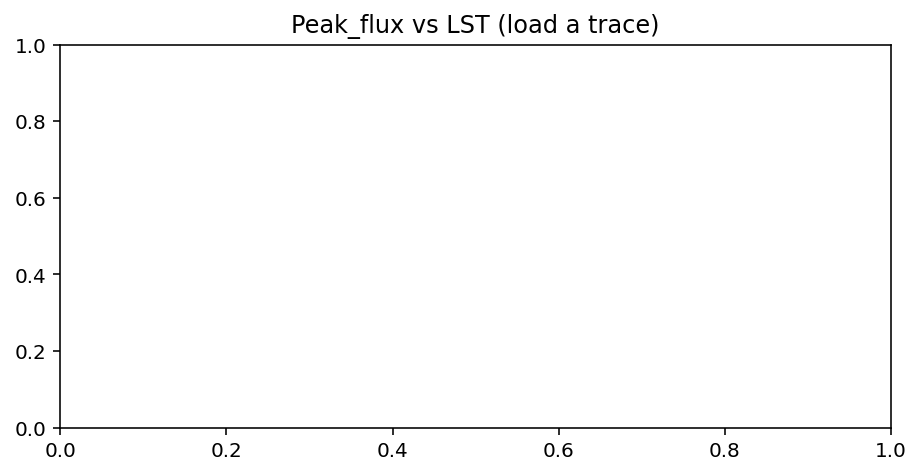
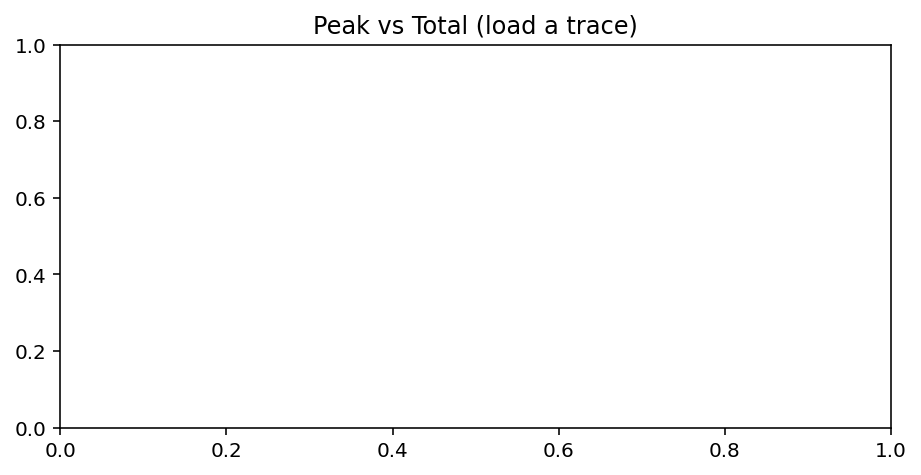
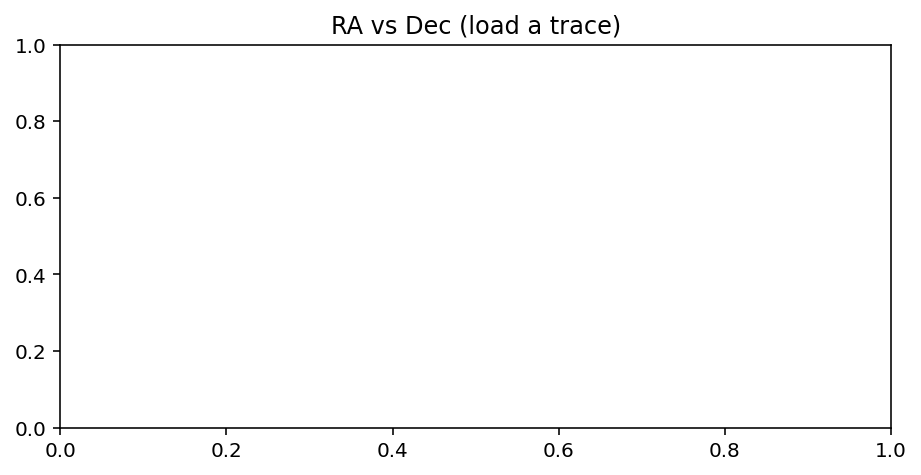
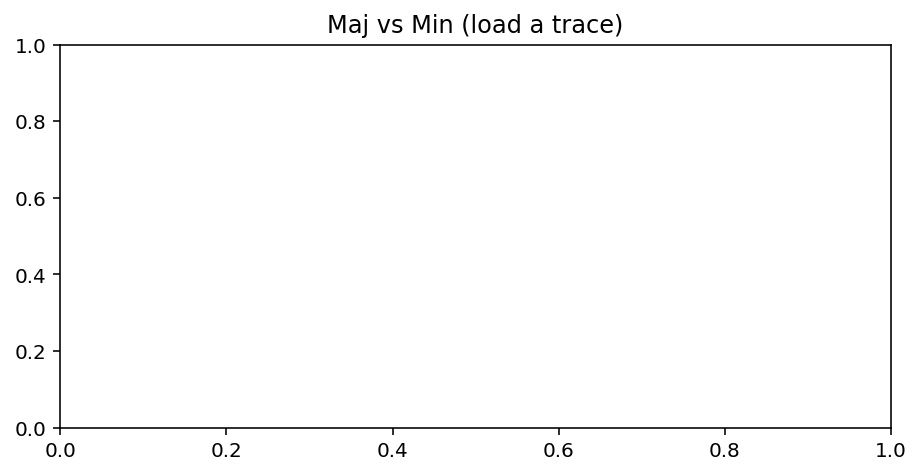

In [7]:
import json
import threading
import urllib.error
import urllib.request

import astropy.units as u
import panel as pn
import param
from astropy.coordinates import SkyCoord

from lwa_catalog.analyze import (
    filter_by_quality_flags,
    plot_maj_min_scatter,
    plot_member_property_scatter,
    plot_peak_flux_vs_lst,
    plot_ra_dec_scatter,
    preferred_trace_columns,
    quality_flag_names,
    rematch_meta_source,
)
from lwa_catalog.io import read_table
from lwa_catalog.viz.aladin import filter_catalog_fov, overlay_catalog_by_band
from lwa_catalog.viz.coordinates import format_coordinate_deg, nearest_sources

# HiPS tiles load in your web browser (not the Jupyter kernel).
# HIPS_LIST_SERVER — survey names from ``cgi-bin/list-hips.py`` (dropdown; kernel fetch).
# HIPS_SERVER — tile base URL passed to Aladin (browser fetch; can differ from list host).
# If the list fetch fails, scans CATALOG_DIR for HiPS ``properties`` directories.
# Example: serve coadd tiles locally:
#   python -m http.server 8000 --directory /fast/claw/metacatalog_coadd2
#   HIPS_LIST_SERVER = "http://localhost:8000"
#   HIPS_SERVER = "http://localhost:8000"
HIPS_LIST_SERVER = "http://lwacalim10:3005"  # or http://localhost:3005 when SSH-tunneled
HIPS_SERVER = "http://localhost:3005"


def default_hips_survey_candidate(bands: tuple[str, ...]) -> str:
    """Preferred HiPS survey stem for RGB/Full or frequency-labeled catalogs."""
    rgb_suffix = (
        "_I_deep_Taper_Robust-0.75_pbcorr_coadd_mosaic_jysr_feather_allsky_"
        "20241218-20250823_N023.hips"
    )
    if "Blue" in bands:
        return f"Blue{rgb_suffix}"
    mhz = sorted(
        (band for band in bands if band.endswith("MHz")),
        key=lambda band: int(band.removesuffix("MHz")),
    )
    if mhz:
        pick = mhz[-1]  # highest-frequency subband present in catalog
        return f"{pick}{rgb_suffix}"
    return f"Blue{rgb_suffix}"


DEFAULT_HIPS_SURVEY = default_hips_survey_candidate(BANDS)
SKY_FOV_DEG = 10.0
HIPS_VIEW_HEIGHT = 700
OVERLAY_MAX_SOURCES_DEFAULT = 1000
OVERLAY_MAX_SOURCES_BOUNDS = (100, 2000)

QUALITY_BIT_OPTIONS = quality_flag_names()
QUALITY_MATCH_OPTIONS = {"Any set": "any", "All set": "all", "None set": "none"}
QUALITY_MATCH_LABELS = {code: label for label, code in QUALITY_MATCH_OPTIONS.items()}

pn.extension(throttled=True)
pn.extension('tabulator')

def discover_local_hips_surveys(catalog_dir: Path = layout.root) -> list[str]:
    """Find HiPS tile directories under ``catalog_dir`` (dirs containing ``properties``)."""
    root = Path(catalog_dir)
    if not root.is_dir():
        return []
    return sorted(
        child.name
        for child in root.iterdir()
        if child.is_dir() and (child / "properties").is_file()
    )


def fetch_hips_surveys(
    list_base: str = HIPS_LIST_SERVER,
    *,
    catalog_dir: Path = layout.root,
    timeout: float = 5.0,
) -> list[str]:
    """Return HiPS survey names from ``list_base``, with local catalog fallback."""
    local = discover_local_hips_surveys(catalog_dir)
    url = f"{list_base.rstrip('/')}/cgi-bin/list-hips.py"
    try:
        with urllib.request.urlopen(url, timeout=timeout) as resp:
            remote = [str(s) for s in json.loads(resp.read().decode())]
    except (OSError, urllib.error.URLError, json.JSONDecodeError, TimeoutError) as exc:
        print(f"Warning: could not fetch HiPS surveys from {url}: {exc}")
        if local:
            print(
                f"Using {len(local)} HiPS director{'y' if len(local) == 1 else 'ies'} "
                f"under {catalog_dir}"
            )
            return sorted({DEFAULT_HIPS_SURVEY, *local})
        print(f"Falling back to DEFAULT_HIPS_SURVEY={DEFAULT_HIPS_SURVEY!r}")
        return [DEFAULT_HIPS_SURVEY]
    return sorted({DEFAULT_HIPS_SURVEY, *remote, *local})


def default_hips_survey(surveys: list[str]) -> str:
    """Pick a sensible default HiPS survey from the server list."""
    if DEFAULT_HIPS_SURVEY in surveys:
        return DEFAULT_HIPS_SURVEY
    default_name = Path(DEFAULT_HIPS_SURVEY).name
    hit = next((s for s in surveys if default_name in s or Path(s).name == default_name), None)
    if hit is not None:
        return hit
    return surveys[0] if surveys else DEFAULT_HIPS_SURVEY


def hips_survey_url(survey: str, *, base: str = HIPS_SERVER) -> str:
    """Build the HiPS root URL passed to ipyaladin (trailing slash for Aladin Lite)."""
    survey = survey.strip().strip("/")
    if survey.startswith("http://") or survey.startswith("https://"):
        return survey if survey.endswith("/") else f"{survey}/"
    return f"{base.rstrip('/')}/{survey}/"


def parse_coordinate(text: str) -> SkyCoord:
    """Parse a single sky position from free-form text."""
    text = text.strip()
    if not text:
        raise ValueError("Coordinate string is empty")
    parts = text.replace(",", " ").split()
    if len(parts) == 2:
        try:
            ra = float(parts[0])
            dec = float(parts[1])
            return SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
        except ValueError:
            pass
    return SkyCoord(text, frame="icrs")


def discover_catalog_parquets(catalog_dir: Path = layout.root) -> list[str]:
    """Relative paths of ``*.parquet`` files under ``catalog_dir`` (top-level first)."""
    root = Path(catalog_dir)
    if not root.is_dir():
        return []
    rels = [
        str(path.relative_to(root))
        for path in root.rglob("*.parquet")
        if path.is_file()
    ]
    top = sorted(name for name in rels if "/" not in name)
    nested = sorted(name for name in rels if name not in top)
    return top + nested


def default_catalog_parquet(options: list[str]) -> str:
    """Prefer ``metacatalog.parquet``, then any available option."""
    preferred = []
    meta_path = PATHS.get("metacatalog")
    if meta_path is not None:
        try:
            preferred.append(str(Path(meta_path).relative_to(layout.root)))
        except ValueError:
            preferred.append(Path(meta_path).name)
    preferred.append("metacatalog.parquet")
    for name in preferred:
        if name in options:
            return name
    return options[0] if options else "metacatalog.parquet"


CATALOG_KEYS: list[str] = discover_catalog_parquets() or ["metacatalog.parquet"]
DEFAULT_CATALOG = default_catalog_parquet(CATALOG_KEYS)
print(f"overlay catalogs: {len(CATALOG_KEYS)} parquet files under {layout.root}")
print(f"DEFAULT_CATALOG = {DEFAULT_CATALOG}")
print(f"DEFAULT_HIPS_SURVEY = {DEFAULT_HIPS_SURVEY}")


def catalog_overlay_name(catalog_key: str) -> str:
    """Parquet stem passed to overlay band resolution."""
    return Path(catalog_key).stem


def load_catalog(catalog_key: str, cache: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Load a Parquet catalog, reusing the in-memory quality table when it matches."""
    if catalog_key in cache:
        return cache[catalog_key]
    rel = str(catalog_key)
    meta_path = PATHS.get("metacatalog")
    meta_rel = None
    if meta_path is not None:
        try:
            meta_rel = str(Path(meta_path).relative_to(layout.root))
        except ValueError:
            meta_rel = Path(meta_path).name
    if meta_rel is not None and rel in {meta_rel, Path(meta_path).name}:
        df = quality.catalog
    else:
        path = (layout.root / rel).resolve()
        if not path.is_file():
            msg = f"Catalog Parquet not found: {path}"
            raise FileNotFoundError(msg)
        df = read_table(path)
    cache[catalog_key] = df
    return df


def overlay_bit_filter_applies(df: pd.DataFrame) -> bool:
    """True when the selected table carries ``quality_flag``."""
    return "quality_flag" in df.columns


def filter_overlay_catalog(
    df: pd.DataFrame,
    bit_names: list[str],
    match: str,
) -> pd.DataFrame:
    """Apply the quality-bit overlay filter; no-op without flags or empty bits."""
    if not overlay_bit_filter_applies(df) or not bit_names:
        return df
    return filter_by_quality_flags(df, bit_names, match=match)


def overlay_filter_status(df: pd.DataFrame, bit_names: list[str], match: str) -> str:
    """Short overlay-status clause describing the active bit filter."""
    if not overlay_bit_filter_applies(df):
        return "bit filter off (no quality_flag)"
    if not bit_names:
        return "no bit filter"
    bits = ", ".join(bit_names)
    return f"{QUALITY_MATCH_LABELS.get(match, match)} [{bits}]"




def _mpl_configure() -> None:
    """Use a non-interactive backend once per kernel (Panel owns display)."""
    import matplotlib

    if matplotlib.get_backend().lower() != "agg":
        matplotlib.use("agg")


def _close_mpl_figure(fig) -> None:
    if fig is None:
        return
    import matplotlib.pyplot as plt

    try:
        plt.close(fig)
    except Exception:
        pass


def _mpl_empty_figure(title: str):
    """Create a small Agg figure with a title (for empty trace state)."""
    _mpl_configure()
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.set_title(title)
    fig.tight_layout()
    return fig


def _set_mpl_pane(pane, fig) -> None:
    """Assign a Matplotlib pane figure and close any replaced handle."""
    old = pane.object
    if old is fig:
        pane.param.trigger("object")
        return
    pane.object = fig
    _close_mpl_figure(old)


def _trace_figures(source_matches: pd.DataFrame, figures: tuple | None = None):
    """Build consistency figures (flux, RA/Dec, Maj/Min) for Panel."""
    _mpl_configure()
    import matplotlib.pyplot as plt

    def _axis(i: int, figsize: tuple[float, float]):
        if figures is not None and i < len(figures) and figures[i] is not None:
            fig = figures[i]
            fig.clf()
            return fig, fig.add_subplot(111)
        return plt.subplots(figsize=figsize)

    fig1, ax1 = _axis(0, (6.5, 3.4))
    plot_peak_flux_vs_lst(source_matches, ax=ax1)
    fig1.tight_layout()

    fig2, ax2 = _axis(1, (6.5, 3.4))
    plot_member_property_scatter(source_matches, ax=ax2)
    fig2.tight_layout()

    fig3, ax3 = _axis(2, (6.5, 3.4))
    plot_ra_dec_scatter(source_matches, ax=ax3)
    fig3.tight_layout()

    fig4, ax4 = _axis(3, (6.5, 3.4))
    plot_maj_min_scatter(source_matches, ax=ax4)
    fig4.tight_layout()
    return fig1, fig2, fig3, fig4


class ReliabilityHiPSViewer(pn.viewable.Viewer):
    """Mix-and-match catalog + HiPS sky view with bitmask-filtered overlays + source trace."""

    catalog = param.Selector(default=DEFAULT_CATALOG, objects=CATALOG_KEYS)
    show_overlay = param.Boolean(default=True, doc="Draw catalog sources on the HiPS view")
    max_sources = param.Integer(
        default=OVERLAY_MAX_SOURCES_DEFAULT,
        bounds=OVERLAY_MAX_SOURCES_BOUNDS,
        doc="Max sources drawn inside the current FOV",
    )
    coordinate = param.String(
        default="83.633 -5.391",
        doc="Center coordinate (decimal deg or sexagesimal)",
    )
    meta_id = param.Integer(default=0, bounds=(0, None), doc="Metacatalog meta_id to rematch")

    def __init__(self, **params):
        super().__init__(**params)
        self._catalog_cache: dict[str, pd.DataFrame] = {}
        self._hips_current_survey = ""
        self._overlay_refresh_timer: threading.Timer | None = None
        self._trace = None
        self._ready = False

        hips_surveys = fetch_hips_surveys()
        hips_default = default_hips_survey(hips_surveys)
        init_coord = parse_coordinate(self.coordinate)

        from ipyaladin import Aladin

        self._catalog_w = pn.widgets.Select.from_param(
            self.param.catalog, name="Catalog", sizing_mode="stretch_width"
        )
        self._hips_survey_w = pn.widgets.Select(
            name="HiPS survey",
            options=hips_surveys,
            value=hips_default,
            sizing_mode="stretch_width",
        )
        self._bits_w = pn.widgets.MultiChoice(
            name="Quality bits",
            options=QUALITY_BIT_OPTIONS,
            value=[],
            solid=False,
            sizing_mode="stretch_width",
        )
        self._match_w = pn.widgets.RadioBoxGroup(
            name="Bit match",
            options=QUALITY_MATCH_OPTIONS,
            value="any",
            inline=True,
        )
        self._hips_fov_w = pn.widgets.FloatSlider(
            name="FOV (deg)",
            start=1,
            end=90.0,
            value=SKY_FOV_DEG,
            step=0.05,
        )
        self._overlay_w = pn.widgets.Checkbox.from_param(
            self.param.show_overlay,
            name="Show catalog overlay",
        )
        self._max_sources_w = pn.widgets.IntInput.from_param(
            self.param.max_sources,
            name="Max sources in view",
            width=160,
        )
        self._coord_w = pn.widgets.TextInput.from_param(
            self.param.coordinate, name="Coordinate", placeholder="RA Dec"
        )
        self._center_btn = pn.widgets.Button(name="Center view", button_type="primary")
        self._center_btn.on_click(self._on_center_click)

        self._meta_id_w = pn.widgets.IntInput.from_param(
            self.param.meta_id, name="meta_id", width=140
        )
        self._trace_btn = pn.widgets.Button(
            name="Load trace",
            button_type="primary",
            width=150,
            sizing_mode="fixed",
        )
        self._trace_btn.on_click(self._on_load_trace)

        self._hips_status = pn.pane.Markdown(
            "_Click the map to select the nearest in-FOV `meta_id`, then **Load trace**._",
            sizing_mode="stretch_width",
        )
        self._overlay_status = pn.pane.Markdown("", sizing_mode="stretch_width")
        self._trace_status = pn.pane.Markdown(
            "_Click the map (or set `meta_id`), then **Load trace**._",
            sizing_mode="stretch_width",
        )

        self._lst_trace_table = pn.widgets.Tabulator(
            pd.DataFrame(),
            pagination=None,
            height=180,
            sizing_mode="stretch_width",
            layout="fit_data_table",
            show_index=False,
            disabled=True,
            sortable=True,
        )
        self._src_trace_table = pn.widgets.Tabulator(
            pd.DataFrame(),
            pagination="local",
            page_size=25,
            height=260,
            sizing_mode="stretch_width",
            layout="fit_data_table",
            show_index=False,
            disabled=True,
            sortable=True,
        )
        empty1 = _mpl_empty_figure("Peak_flux vs LST (load a trace)")
        empty2 = _mpl_empty_figure("Peak vs Total (load a trace)")
        empty3 = _mpl_empty_figure("RA vs Dec (load a trace)")
        empty4 = _mpl_empty_figure("Maj vs Min (load a trace)")
        self._flux_plot = pn.pane.Matplotlib(empty1, tight=True, height=320)
        self._scatter_plot = pn.pane.Matplotlib(empty2, tight=True, height=320)
        self._radec_plot = pn.pane.Matplotlib(empty3, tight=True, height=320)
        self._majmin_plot = pn.pane.Matplotlib(empty4, tight=True, height=320)

        self._hips_current_survey = hips_survey_url(hips_default)
        self._aladin = Aladin(
            survey=self._hips_current_survey,
            target=init_coord,
            fov=SKY_FOV_DEG,
            height=HIPS_VIEW_HEIGHT,
        )
        self._hips_view = pn.pane.IPyWidget(
            self._aladin,
            height=HIPS_VIEW_HEIGHT + 20,
            sizing_mode="stretch_width",
        )
        self._aladin.observe(self._on_aladin_view_trait, names=["_target", "_fov"])
        self._aladin.set_listener("click", self._on_sky_click)

        self._catalog_w.param.watch(self._on_catalog_change, "value")
        self._hips_survey_w.param.watch(self._on_hips_survey_change, "value")
        self._hips_fov_w.param.watch(self._on_hips_fov_change, "value")
        self._overlay_w.param.watch(self._on_overlay_change, "value")
        self._max_sources_w.param.watch(self._on_max_sources_change, "value")
        self._bits_w.param.watch(self._on_bit_filter_change, "value")
        self._match_w.param.watch(self._on_bit_filter_change, "value")

        self._panel = pn.Column(
            pn.pane.Markdown("### Sky context (HiPS + catalog overlay)", disable_anchors=True),
            pn.Row(self._catalog_w, self._hips_survey_w),
            self._bits_w,
            pn.Row(self._match_w, self._overlay_w, self._max_sources_w),
            pn.Row(self._hips_fov_w, self._coord_w, self._center_btn),
            self._hips_status,
            self._overlay_status,
            self._hips_view,
            pn.pane.Markdown(
                "### Source trace (rematch)\n"
                "Click the map to select the nearest in-FOV `meta_id` (uses the active "
                "catalog + quality-bit filter), then **Load trace**. Rematch uses beam "
                "association; durable key `(band, lst_hour, Source_id)`. Does not change "
                "the sky overlay.",
                disable_anchors=True,
            ),
            pn.Row(self._meta_id_w, self._trace_btn, align="end"),
            self._trace_status,
            pn.pane.Markdown("#### LST-merged matches", disable_anchors=True),
            self._lst_trace_table,
            pn.pane.Markdown("#### Per-hour source matches", disable_anchors=True),
            self._src_trace_table,
            pn.Row(self._flux_plot, self._scatter_plot),
            pn.Row(self._radec_plot, self._majmin_plot),
        )

        self._ready = True
        self._sync_bit_widgets()
        self._update_sky_view(init_coord)

    def __panel__(self):
        return self._panel

    def _view_coord(self) -> SkyCoord:
        return parse_coordinate(self.coordinate)

    def _overlay_view(self) -> tuple[SkyCoord, float]:
        """Current Aladin center and FOV for viewport-limited overlays."""
        target = self._aladin.target
        if isinstance(target, SkyCoord):
            coord = target
        else:
            ra, dec = target
            coord = SkyCoord(ra=ra, dec=dec, frame="icrs")
        fov = float(self._aladin.fov.to(u.deg).value)
        return coord, fov

    def _filtered_catalog(self) -> pd.DataFrame:
        """Active overlay catalog with the quality-bit filter applied."""
        df = load_catalog(str(self.catalog), self._catalog_cache)
        bit_names = [str(n) for n in (self._bits_w.value or [])]
        match = str(self._match_w.value)
        return filter_overlay_catalog(df, bit_names, match)

    def _metacatalog_for_trace(self) -> pd.DataFrame:
        """Prefer in-memory quality/fusion tables for rematch; else the overlay catalog."""
        q = globals().get("quality")
        if q is not None and hasattr(q, "catalog"):
            cat = q.catalog
            if isinstance(cat, pd.DataFrame) and "meta_id" in cat.columns and not cat.empty:
                return cat
        meta = globals().get("metacatalog")
        if isinstance(meta, pd.DataFrame) and "meta_id" in meta.columns and not meta.empty:
            return meta
        return load_catalog(str(self.catalog), self._catalog_cache)

    def _set_table_value(self, table, df: pd.DataFrame) -> None:
        table.value = df if df is not None else pd.DataFrame()

    def _clear_trace(self, message: str) -> None:
        self._trace = None
        self._trace_status.object = message
        self._set_table_value(self._lst_trace_table, pd.DataFrame())
        self._set_table_value(self._src_trace_table, pd.DataFrame())
        for pane, title in (
            (self._flux_plot, "Peak_flux vs LST (load a trace)"),
            (self._scatter_plot, "Peak vs Total (load a trace)"),
            (self._radec_plot, "RA vs Dec (load a trace)"),
            (self._majmin_plot, "Maj vs Min (load a trace)"),
        ):
            _set_mpl_pane(pane, _mpl_empty_figure(title))

    def _on_aladin_view_trait(self, _change) -> None:
        if not self._ready:
            return
        self._schedule_overlay_refresh()

    def _schedule_overlay_refresh(self) -> None:
        timer = self._overlay_refresh_timer
        if timer is not None:
            timer.cancel()
        self._overlay_refresh_timer = threading.Timer(0.35, self._refresh_overlay_from_aladin)
        self._overlay_refresh_timer.daemon = True
        self._overlay_refresh_timer.start()

    def _refresh_overlay_from_aladin(self) -> None:
        if not self._ready or not self.show_overlay:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._overlay_status.object = f"**Overlay refresh failed:** `{exc}`"

    def _set_hips_survey(self, survey_name: str) -> None:
        url = hips_survey_url(survey_name)
        if url == self._hips_current_survey:
            return
        self._aladin.survey = url
        self._hips_current_survey = url

    def _refresh_overlay(
        self,
        coord: SkyCoord | None = None,
        *,
        fov_deg: float | None = None,
    ) -> None:
        view_coord, view_fov = self._overlay_view()
        if coord is None:
            coord = view_coord
        if fov_deg is None:
            fov_deg = view_fov

        catalog_key = str(self.catalog)
        catalog_name = catalog_overlay_name(catalog_key)
        fov = float(fov_deg)

        if not self.show_overlay:
            overlay_catalog_by_band(
                self._aladin,
                pd.DataFrame(),
                catalog_name,
                coord,
                fov,
                replace=True,
            )
            self._overlay_status.object = "_Catalog overlay off._"
            return

        try:
            df = self._filtered_catalog()
        except (FileNotFoundError, KeyError) as exc:
            self._overlay_status.object = f"**Overlay failed:** `{exc}`"
            return

        bit_names = [str(n) for n in (self._bits_w.value or [])]
        match = str(self._match_w.value)

        result = overlay_catalog_by_band(
            self._aladin,
            df,
            catalog_name,
            coord,
            fov,
            max_rows=int(self.max_sources),
        )
        cap_note = f" (capped at {self.max_sources})" if result.truncated else ""
        cat_label = catalog_key
        filt = overlay_filter_status(df, bit_names, match)
        self._overlay_status.object = (
            f"**Overlay:** {result.drawn} drawn, {result.in_fov} in FOV{cap_note} "
            f"— {cat_label}; {filt} on `{self._hips_survey_w.value}`."
        )

    def _update_sky_view(self, coord: SkyCoord) -> None:
        self._set_hips_survey(str(self._hips_survey_w.value))
        self._aladin.target = coord
        self._aladin.fov = float(self._hips_fov_w.value)
        self._hips_status.object = (
            f"Centered on RA={coord.ra.deg:.6f}, Dec={coord.dec.deg:.6f} "
            f"(FOV={self._hips_fov_w.value:.2f}°). Click map to pick nearest `meta_id`."
        )
        self._refresh_overlay(coord)

    def _sync_bit_widgets(self) -> None:
        try:
            df = load_catalog(str(self.catalog), self._catalog_cache)
            enabled = overlay_bit_filter_applies(df)
        except (FileNotFoundError, KeyError, OSError):
            enabled = False
        self._bits_w.disabled = not enabled
        self._match_w.disabled = not enabled

    def _select_meta_id(self, meta_id: int, *, sep_arcmin: float | None = None) -> None:
        self.meta_id = int(meta_id)
        try:
            df = self._metacatalog_for_trace()
            hits = df.loc[df["meta_id"] == meta_id] if "meta_id" in df.columns else df.iloc[0:0]
            if not hits.empty:
                row = hits.iloc[0]
                ra = float(row["RA"])
                dec = float(row["DEC"])
                if np.isfinite(ra) and np.isfinite(dec):
                    self.coordinate = format_coordinate_deg(ra, dec)
        except Exception:
            pass
        label = f"**meta_id={meta_id}**"
        if sep_arcmin is not None:
            label += f" — nearest at **{sep_arcmin:.3f} arcmin** from click"
        self._hips_status.object = f"{label}. Click **Load trace** for rematch tables/plots."

    def _handle_sky_click(self, content: dict) -> None:
        """Select the nearest in-FOV meta_id (always on)."""
        if not getattr(self, "_ready", False):
            return
        try:
            ra = float(content["ra"])
            dec = float(content["dec"])
        except (KeyError, TypeError, ValueError):
            return

        coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
        try:
            df = self._filtered_catalog()
            if df.empty or "meta_id" not in df.columns:
                self._hips_status.object = (
                    "**Sky pick needs a catalog with a `meta_id` column "
                    "(and rows after the bit filter).**"
                )
                return
            center, fov = self._overlay_view()
            in_fov = filter_catalog_fov(df, center, fov)
            if in_fov.empty:
                in_fov = df
            hits = nearest_sources(in_fov, coord, n=1)
        except Exception as exc:
            self._hips_status.object = f"**Sky pick failed:** `{exc}`"
            return

        nearest = hits.iloc[0]
        if "meta_id" not in nearest.index or pd.isna(nearest.get("meta_id")):
            self._hips_status.object = "**Nearest source has no meta_id.**"
            return
        self._select_meta_id(int(nearest["meta_id"]), sep_arcmin=float(nearest["sep_arcmin"]))

    def _on_sky_click(self, content: dict) -> None:
        def _handle() -> None:
            self._handle_sky_click(content)

        try:
            pn.state.execute(_handle)
        except Exception:
            _handle()

    def _on_load_trace(self, _event=None) -> None:
        self._run_trace(int(self.meta_id))

    def _run_trace(self, meta_id: int) -> None:
        try:
            meta_df = self._metacatalog_for_trace()
            if "meta_id" not in meta_df.columns:
                raise ValueError("trace catalog has no meta_id column")
            if meta_id not in set(meta_df["meta_id"].dropna().astype(int)):
                raise ValueError(f"meta_id={meta_id} not found in rematch catalog")
            lst_cache = globals().get("lst_merged")
            if not isinstance(lst_cache, dict):
                lst_cache = None
            trace = rematch_meta_source(
                meta_df, layout, meta_id=meta_id, lst_merged=lst_cache
            )
        except Exception as exc:
            self._clear_trace(f"**Trace failed for meta_id={meta_id}:** `{exc}`")
            return

        self._trace = trace
        self.meta_id = int(trace.meta_id)
        warn = ""
        if trace.warnings:
            warn = "  \n" + "  \n".join(f"- {w}" for w in trace.warnings)
        n_lst_meta = trace.meta_row.get("n_lst_contributions", "—")
        self._trace_status.object = (
            f"**meta_id={trace.meta_id}** — "
            f"LST matches: {len(trace.lst_matches)}, "
            f"source matches: {len(trace.source_matches)} "
            f"(meta `n_lst_contributions`={n_lst_meta}).{warn}"
        )

        lst_cols = preferred_trace_columns(trace.lst_matches)
        src_cols = preferred_trace_columns(trace.source_matches)
        self._set_table_value(
            self._lst_trace_table,
            trace.lst_matches.loc[:, lst_cols] if lst_cols else trace.lst_matches,
        )
        self._set_table_value(
            self._src_trace_table,
            trace.source_matches.loc[:, src_cols] if src_cols else trace.source_matches,
        )
        figs = (
            self._flux_plot.object,
            self._scatter_plot.object,
            self._radec_plot.object,
            self._majmin_plot.object,
        )
        fig1, fig2, fig3, fig4 = _trace_figures(trace.source_matches, figures=figs)
        for pane, fig in (
            (self._flux_plot, fig1),
            (self._scatter_plot, fig2),
            (self._radec_plot, fig3),
            (self._majmin_plot, fig4),
        ):
            _set_mpl_pane(pane, fig)

    def _on_catalog_change(self, _event=None) -> None:
        if not self._ready:
            return
        self._sync_bit_widgets()
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._overlay_status.object = f"**Overlay refresh failed:** `{exc}`"

    def _on_bit_filter_change(self, _event=None) -> None:
        if not self._ready:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._overlay_status.object = f"**Overlay refresh failed:** `{exc}`"

    def _on_hips_survey_change(self, _event=None) -> None:
        self._set_hips_survey(str(self._hips_survey_w.value))
        try:
            self._refresh_overlay()
        except Exception:
            pass

    def _on_hips_fov_change(self, _event=None) -> None:
        self._aladin.fov = float(self._hips_fov_w.value)
        try:
            self._refresh_overlay()
        except Exception:
            pass

    def _on_overlay_change(self, _event=None) -> None:
        if not self._ready:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._overlay_status.object = f"**Overlay refresh failed:** `{exc}`"

    def _on_max_sources_change(self, _event=None) -> None:
        if not self._ready:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._overlay_status.object = f"**Overlay refresh failed:** `{exc}`"

    def _on_center_click(self, _event=None) -> None:
        try:
            coord = parse_coordinate(self.coordinate)
        except Exception as exc:
            self._hips_status.object = f"**Center failed:** `{exc}`"
            return
        self._update_sky_view(coord)


hips_viewer = ReliabilityHiPSViewer()
hips_viewer


## Make subsets

In [8]:
from lwa_catalog.analyze import quality_flag_mask_from_names
from lwa_catalog.io import write_table

In [9]:
# Edit this list to compose a bitmask; rows with any listed bit set are dropped.
EXCLUDE_FLAGS = [
    "HAS_NAN",
    "INVALID_ASTROMETRY",
    "UNPHYSICAL_FLUX",
    "RESID_ABS_FAIL",
    "RESID_PCTL_RMS",
    "RESID_PCTL_MEAN",
    "JITTER_FAIL",
    "LARGE_SINGLE",
]
mask = quality_flag_mask_from_names(EXCLUDE_FLAGS)
print("EXCLUDE_FLAGS =", EXCLUDE_FLAGS)
print("mask =", mask)

EXCLUDE_FLAGS = ['HAS_NAN', 'INVALID_ASTROMETRY', 'UNPHYSICAL_FLUX', 'RESID_ABS_FAIL', 'RESID_PCTL_RMS', 'RESID_PCTL_MEAN', 'JITTER_FAIL', 'LARGE_SINGLE']
mask = 33267


In [10]:
mask

33267

In [11]:
if WRITE_SUBSET:
    kept = metacatalog.loc[(quality.catalog['quality_flag'] & mask) == 0]
    out = layout.root / f"metacatalog_resid_mask{mask}.parquet"
    assert out.name != "metacatalog.parquet"
    write_table(kept, out)
    print(f"wrote {len(kept)} / {len(quality.catalog)} → {out}")